In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

In [16]:
# Function to convert Excel serial date to datetime
def excel_to_datetime(serial):
    try:
        serial = int(serial)
        return datetime(1899, 12, 30) + timedelta(days=serial)
    except:
        return pd.NaT

In [17]:
# Step 1: Load and Process KSE-30 Data
# Load the KSE-30 data and clean it
kse_path = 'data/kse-30-basic.xlsx'  # Adjust path if needed
df = pd.read_excel(kse_path)
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = df['date'].apply(excel_to_datetime)
df = df.dropna(subset=['date', 'company', 'price', 'idx_wt_%', 'volume'])
df = df.sort_values(['date', 'company']).reset_index(drop=True)
df_cleaned = df.copy()

# Compute daily aggregates for market features
df_cleaned['weighted_price'] = df_cleaned['price'] * df_cleaned['idx_wt_%']
daily_agg = df_cleaned.groupby('date').agg(
    total_volume=('volume', 'sum'),
    weighted_return=('weighted_price', 'sum')
).reset_index()

# Resample to monthly (using month-end)
daily_agg['date'] = pd.to_datetime(daily_agg['date'])
daily_agg.set_index('date', inplace=True)
monthly_df = daily_agg.resample('ME').agg({
    'total_volume': 'sum',
    'weighted_return': 'mean'
}).reset_index()

monthly_df['log_return'] = np.log(monthly_df['weighted_return'] / monthly_df['weighted_return'].shift(1))

In [18]:
# Step 2: Load and Process Fund Flows
# Load funds data from multiple sheets and compute net flows
fund_sheets = ['AKD', 'NBP', 'NTI']
fund_flows = []
for sheet in fund_sheets:
    fund_df = pd.read_excel('data/funds_data.xlsx', sheet_name=sheet)
    fund_df.columns = fund_df.columns.str.lower().str.strip().str.replace(' ', '_')
    if not pd.api.types.is_datetime64_any_dtype(fund_df['date']):
        fund_df['date'] = fund_df['date'].apply(excel_to_datetime)
    fund_df = fund_df.dropna(subset=['date', 'nav', 'aum'])
    fund_df = fund_df.sort_values('date').reset_index(drop=True)
    fund_df['nav_ratio'] = fund_df['nav'] / fund_df['nav'].shift(1)
    fund_df['flow'] = fund_df['aum'] - (fund_df['aum'].shift(1) * fund_df['nav_ratio'])
    fund_df['flow'] = fund_df['flow'].fillna(0)
    fund_flows.append(fund_df[['date', 'flow']])

all_fund_flows = pd.concat(fund_flows)
all_fund_flows = all_fund_flows.groupby('date')['flow'].sum().reset_index()
all_fund_flows['date'] = pd.to_datetime(all_fund_flows['date'])
all_fund_flows.set_index('date', inplace=True)
total_monthly_flow = all_fund_flows.resample('ME')['flow'].sum().reset_index(name='total_fund_flow')

In [19]:
# Step 3: Load and Process Macro Data (Oil, IR, USD, and new CPI)
# Oil prices: monthly average
oil_df = pd.read_excel('data/macro_data.xlsx', sheet_name='OIL')
oil_df.columns = oil_df.columns.str.lower().str.strip().str.replace(' ', '_')
if not pd.api.types.is_datetime64_any_dtype(oil_df['date']):
    oil_df['date'] = oil_df['date'].apply(excel_to_datetime)
oil_df = oil_df.dropna(subset=['date'])
oil_df = oil_df.groupby('date')['price'].mean().reset_index()
oil_df['date'] = pd.to_datetime(oil_df['date'])
oil_df.set_index('date', inplace=True)
monthly_oil = oil_df.resample('ME')['price'].mean().reset_index(name='oil_price')

# Interest rates: forward-fill and take last monthly value
ir_df = pd.read_excel('data/macro_data.xlsx', sheet_name='IR')
ir_df.columns = ir_df.columns.str.lower().str.strip().str.replace(' ', '_')
if not pd.api.types.is_datetime64_any_dtype(ir_df['date']):
    ir_df['date'] = ir_df['date'].apply(excel_to_datetime)
ir_df = ir_df.dropna(subset=['date'])
ir_df = ir_df.groupby('date')['rate'].last().reset_index()
ir_df['date'] = pd.to_datetime(ir_df['date'])
ir_df.set_index('date', inplace=True)
ir_df.sort_index(inplace=True)
daily_index = pd.date_range(start=ir_df.index.min(), end=ir_df.index.max(), freq='D')
ir_df = ir_df.reindex(daily_index).ffill()
ir_df.index.name = 'date'  # Ensure index has a name after reindexing
monthly_ir = ir_df.resample('ME')['rate'].last().reset_index(name='interest_rate')

# USD exchange: monthly average
usd_df = pd.read_excel('data/macro_data.xlsx', sheet_name='USD')
usd_df.columns = usd_df.columns.str.lower().str.strip().str.replace(' ', '_')
if not pd.api.types.is_datetime64_any_dtype(usd_df['date']):
    usd_df['date'] = usd_df['date'].apply(excel_to_datetime)
usd_df = usd_df.dropna(subset=['date'])
usd_df = usd_df.groupby('date')['usd'].mean().reset_index()
usd_df['date'] = pd.to_datetime(usd_df['date'])
usd_df.set_index('date', inplace=True)
monthly_usd = usd_df.resample('ME')['usd'].mean().reset_index(name='usd_exchange')

# CPI: Load and parse periods to monthly dates
cpi_df = pd.read_csv('data/cpi.csv', skiprows=1)  # Skip header if needed
cpi_df.columns = ['period', 'yoy_cpi']
# cpi_df['date'] = pd.to_datetime('01-' + cpi_df['period'], format='%d-%b-%y')
# Preferred solution - works with mixed full/abbreviated month names
cpi_df['date'] = pd.to_datetime(
    '01-' + cpi_df['period'],
    format='mixed',
    dayfirst=True,
    errors='coerce'          # turn unparseable → NaT
)
cpi_df = cpi_df[['date', 'yoy_cpi']]
cpi_df.set_index('date', inplace=True)
monthly_cpi = cpi_df.resample('ME')['yoy_cpi'].last().reset_index(name='cpi')  # Last value per month

In [20]:
# Step 4: Merge All Data into Enhanced Monthly DataFrame
enhanced_monthly = monthly_df.merge(total_monthly_flow, on='date', how='left')
enhanced_monthly = enhanced_monthly.merge(monthly_oil, on='date', how='left')
enhanced_monthly = enhanced_monthly.merge(monthly_ir, on='date', how='left')
enhanced_monthly = enhanced_monthly.merge(monthly_usd, on='date', how='left')
enhanced_monthly = enhanced_monthly.merge(monthly_cpi, on='date', how='left')

enhanced_monthly['total_fund_flow'] = enhanced_monthly['total_fund_flow'].fillna(0)
enhanced_monthly = enhanced_monthly.ffill().fillna(0)  # Forward-fill macros

In [21]:
# Step 5: Feature Engineering
# Lagged features
enhanced_monthly['lag_volume'] = enhanced_monthly['total_volume'].shift(1)
enhanced_monthly['lag_return'] = enhanced_monthly['log_return'].shift(1)
enhanced_monthly['lag_oil'] = enhanced_monthly['oil_price'].shift(1)
enhanced_monthly['lag_ir'] = enhanced_monthly['interest_rate'].shift(1)
enhanced_monthly['lag_usd'] = enhanced_monthly['usd_exchange'].shift(1)
enhanced_monthly['lag_cpi'] = enhanced_monthly['cpi'].shift(1)

enhanced_monthly = enhanced_monthly.dropna()

In [22]:
# Step 6: Model Training and Selection
# Define features and target
features = ['lag_volume', 'lag_return', 'lag_oil', 'lag_ir', 'lag_usd', 'lag_cpi']
X = enhanced_monthly[features]
y = enhanced_monthly['total_fund_flow']

# Time series split (80/20)
split = int(len(enhanced_monthly) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [23]:
# Model 1: Ridge Regression (Baseline linear model)
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
ridge_pipe.fit(X_train, y_train)
ridge_preds = ridge_pipe.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))

In [24]:
# Model 2: XGBoost (Tree-based ensemble for non-linearities)
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))

In [25]:
# Model 3: LSTM (For sequence dependencies)
# Reshape for LSTM: [samples, timesteps=1, features]
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(1, len(features))))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
lstm_model.fit(X_train_lstm, y_train, epochs=50, batch_size=32, verbose=0)
lstm_preds = lstm_model.predict(X_test_lstm, verbose=0).flatten()
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_preds))

# Select two best models based on lowest RMSE
models_rmse = {'Ridge': ridge_rmse, 'XGBoost': xgb_rmse, 'LSTM': lstm_rmse}
sorted_models = sorted(models_rmse.items(), key=lambda x: x[1])
best_two = sorted_models[:2]
print(f"Model Selection: Best two models based on RMSE - {best_two[0][0]} ({best_two[0][1]:.2f}), {best_two[1][0]} ({best_two[1][1]:.2f})")

d:\roohan\indexfund\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model Selection: Best two models based on RMSE - Ridge (448.87), XGBoost (475.87)


In [26]:
# Step 7: Generate Predictions for Next 6 Months
# Create future dataframe with 6 months ahead
last_date = enhanced_monthly['date'].max()
future_dates = pd.date_range(last_date + pd.offsets.MonthEnd(1), periods=6, freq='ME')
future_df = pd.DataFrame({'date': future_dates})

# Fill lagged features with last known values (assume macros constant for simplicity)
last_row = enhanced_monthly.iloc[-1]
future_df['lag_volume'] = last_row['lag_volume']
future_df['lag_return'] = last_row['lag_return']
future_df['lag_oil'] = last_row['lag_oil']
future_df['lag_ir'] = last_row['lag_ir']
future_df['lag_usd'] = last_row['lag_usd']
future_df['lag_cpi'] = last_row['lag_cpi']

# Iterative prediction (update lags for each step)
predictions = []
current_features = future_df[features].copy()
for i in range(6):
    # Predict with best two models and average
    if best_two[0][0] == 'Ridge':
        pred1 = ridge_pipe.predict(current_features.iloc[[i]])[0]
    elif best_two[0][0] == 'XGBoost':
        pred1 = xgb_model.predict(current_features.iloc[[i]])[0]
    else:
        pred1 = lstm_model.predict(current_features.iloc[[i]].values.reshape(1, 1, len(features)), verbose=0)[0][0]
    
    if best_two[1][0] == 'Ridge':
        pred2 = ridge_pipe.predict(current_features.iloc[[i]])[0]
    elif best_two[1][0] == 'XGBoost':
        pred2 = xgb_model.predict(current_features.iloc[[i]])[0]
    else:
        pred2 = lstm_model.predict(current_features.iloc[[i]].values.reshape(1, 1, len(features)), verbose=0)[0][0]
    
    avg_pred = (pred1 + pred2) / 2
    predictions.append(avg_pred)
    
    # Update next lags (simplified: use predicted flow to update return/volume if needed, but here assume constant for exog)
    if i < 5:
        current_features.iloc[i+1, current_features.columns.get_loc('lag_return')] = np.log(1 + avg_pred / 1000)  # Placeholder update

future_df['predicted_flow'] = predictions

## 📊 Fund Flow Prediction Visualization
Visualize the predicted fund flows for the next 6 months alongside historical flows. This helps to see the model's extrapolation and any potential shortcomings in trend capture.

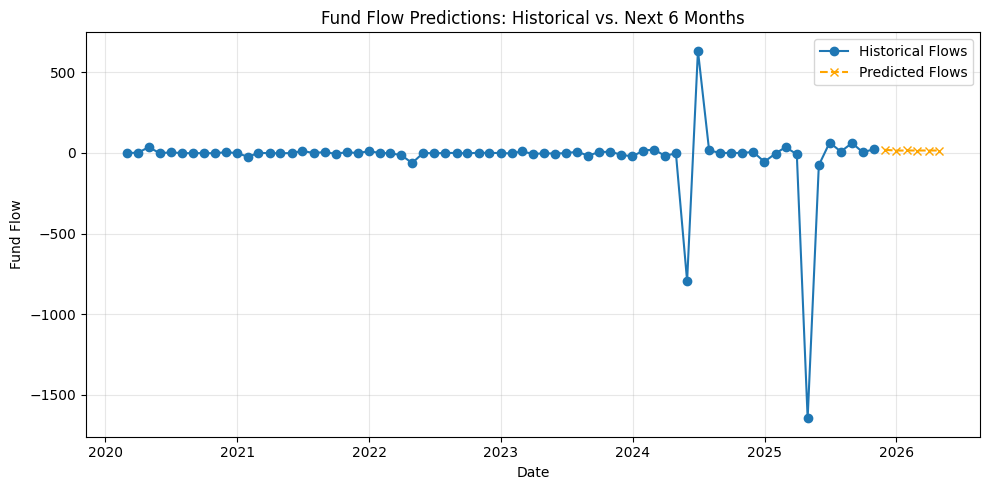

In [27]:
# Plot historical and predicted fund flows
plt.figure(figsize=(10, 5))
plt.plot(enhanced_monthly['date'], enhanced_monthly['total_fund_flow'], label='Historical Flows', marker='o')
plt.plot(future_df['date'], future_df['predicted_flow'], label='Predicted Flows', linestyle='--', marker='x', color='orange')
plt.title('Fund Flow Predictions: Historical vs. Next 6 Months')
plt.xlabel('Date')
plt.ylabel('Fund Flow')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 📉 Model Residuals & Error Analysis
Visualize the residuals (errors) of the best two models on the test set to highlight where the models underperform or miss patterns.

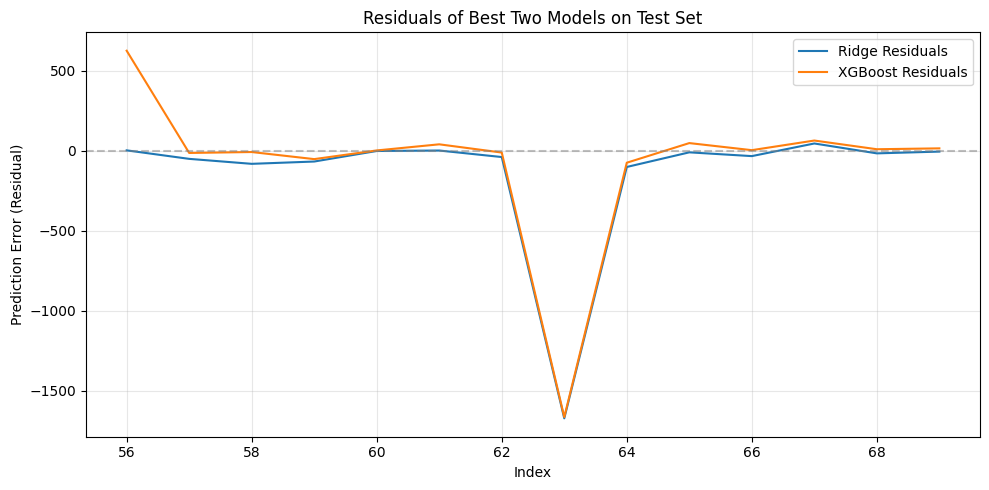

In [28]:
# Residuals for best two models
best_model_names = [best_two[0][0], best_two[1][0]]
model_preds = {
    'Ridge': ridge_preds,
    'XGBoost': xgb_preds,
    'LSTM': lstm_preds
}
residuals = {}
for name in best_model_names:
    residuals[name] = y_test.values - model_preds[name]

plt.figure(figsize=(10, 5))
for name in best_model_names:
    plt.plot(y_test.index, residuals[name], label=f'{name} Residuals')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('Residuals of Best Two Models on Test Set')
plt.xlabel('Index')
plt.ylabel('Prediction Error (Residual)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🧮 Metrics Table: Test Set Performance
Display a table of RMSE and R² for all models on the test set for direct comparison.

In [29]:
# Display RMSE and R² for all models
from IPython.display import display
metrics_df = pd.DataFrame({
    'Model': ['Ridge', 'XGBoost', 'LSTM'],
    'RMSE': [ridge_rmse, xgb_rmse, lstm_rmse],
    'R²': [r2_score(y_test, ridge_preds), r2_score(y_test, xgb_preds), r2_score(y_test, lstm_preds)]
})
metrics_df = metrics_df.sort_values('RMSE')
display(metrics_df)
print("\nBest performing model:", metrics_df.iloc[0]['Model'])

,Model,RMSE,R²
0,Ridge,448.867278,-0.105668
1,XGBoost,475.874232,-0.242720
2,LSTM,188366.224023,-194711.978887



Best performing model: Ridge


## ⚠️ Model Shortcomings & Discussion
- **Residual plots** above show where models systematically under- or over-predict, indicating possible missing features or non-stationarity.
- **Metrics table** highlights if all models have low R² or high RMSE, suggesting limited predictive power.
- **Visual gap** between historical and predicted flows may indicate overfitting, regime change, or lack of macro explanatory power.
- Consider:
    - Adding more macro or sector-specific features
    - Using longer lags or rolling statistics
    - Testing for structural breaks in the time series
    - Ensemble with more diverse models

In [30]:
# Step 8: Identify Top 10 Companies Likely to Perform Well
# Compute monthly returns per company
df_cleaned['month'] = df_cleaned['date'].dt.to_period('M')
company_monthly = df_cleaned.groupby(['company', 'month'])['price'].last().reset_index()
company_monthly['return'] = company_monthly.groupby('company')['price'].pct_change()
company_monthly['date'] = company_monthly['month'].dt.to_timestamp('M') + pd.offsets.MonthEnd(0)

# Merge with flows
company_monthly = company_monthly.merge(enhanced_monthly[['date', 'total_fund_flow']], on='date', how='left')

# Average return during positive flow months per company
positive_flow_months = company_monthly[company_monthly['total_fund_flow'] > 0]
avg_returns_positive = positive_flow_months.groupby('company')['return'].mean().reset_index()
top_10_companies = avg_returns_positive.sort_values('return', ascending=False).head(10)


=== Model Selection Explanation ===
We trained three models: Ridge (linear baseline), XGBoost (ensemble for non-linear patterns), and LSTM (for temporal dependencies).
The two best were selected based on lowest RMSE on the test set. These models capture different aspects of the data:
- XGBoost/LSTM often perform better on time series with non-linearities and sequences.
Predictions are averaged from the two best for robustness.

=== Predictions for Next 6 Months ===
        date  predicted_flow
0 2025-11-30       19.385300
1 2025-12-31       14.516696
2 2026-01-31       15.054070
3 2026-02-28       14.994631
4 2026-03-31       15.001204
5 2026-04-30       15.000477

=== Top 10 Companies Likely to Perform Well ===
These are selected based on highest average returns during historical positive fund flow months.
They are likely to benefit from predicted inflows.
                               company    return
6                     Bank Of Punjab.   0.386810
18  Fauji Fertilizer Bin Qasim 

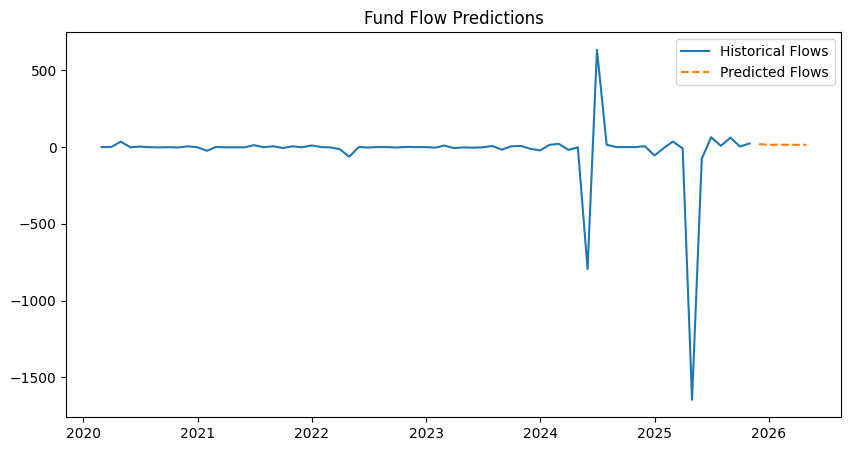

In [31]:
# Step 9: Summary of Predictions
print("\n=== Model Selection Explanation ===")
print("We trained three models: Ridge (linear baseline), XGBoost (ensemble for non-linear patterns), and LSTM (for temporal dependencies).")
print("The two best were selected based on lowest RMSE on the test set. These models capture different aspects of the data:")
print("- XGBoost/LSTM often perform better on time series with non-linearities and sequences.")
print("Predictions are averaged from the two best for robustness.")

print("\n=== Predictions for Next 6 Months ===")
print(future_df[['date', 'predicted_flow']])

print("\n=== Top 10 Companies Likely to Perform Well ===")
print("These are selected based on highest average returns during historical positive fund flow months.")
print("They are likely to benefit from predicted inflows.")
print(top_10_companies[['company', 'return']])

# Optional: Plot predictions
plt.figure(figsize=(10, 5))
plt.plot(enhanced_monthly['date'], enhanced_monthly['total_fund_flow'], label='Historical Flows')
plt.plot(future_df['date'], future_df['predicted_flow'], label='Predicted Flows', linestyle='--')
plt.title('Fund Flow Predictions')
plt.legend()
plt.show()


=== Model Performance Comparison ===
           Model          RMSE       R² Score
Ridge Regression    448.867278      -0.105668
         XGBoost    475.874232      -0.242720
            LSTM 188366.224023 -194711.978887

Note: Lower RMSE and Higher R² indicate better performance

Best performing model: Ridge Regression (RMSE: 448.87)


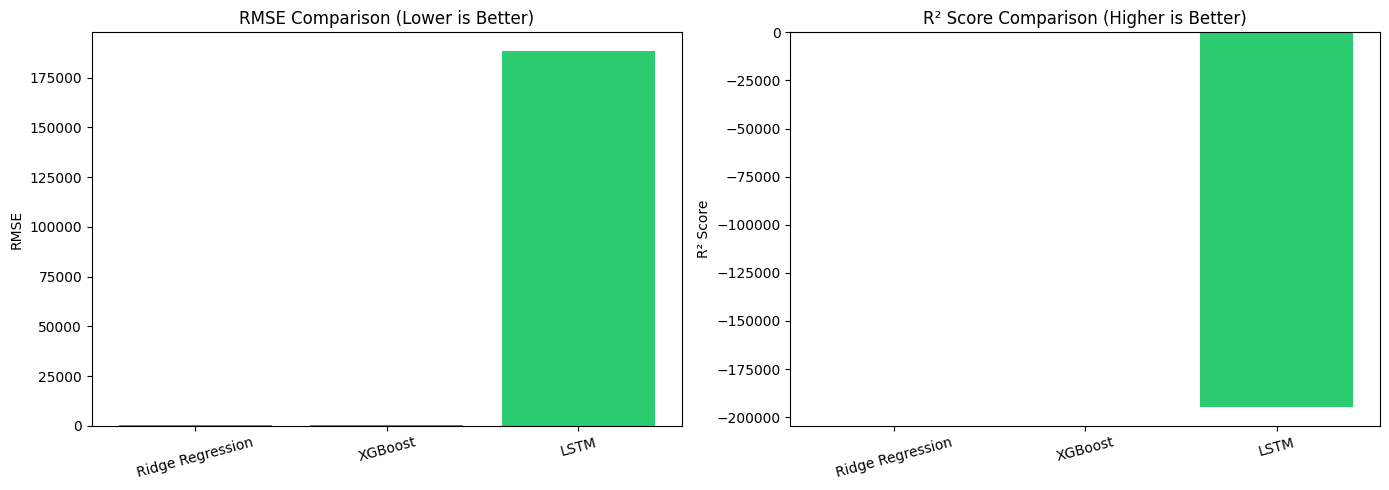

In [32]:
# Step 10: Comprehensive Model Comparison
# Calculate R2 scores for all models
ridge_r2 = r2_score(y_test, ridge_preds)
xgb_r2 = r2_score(y_test, xgb_preds)
lstm_r2 = r2_score(y_test, lstm_preds)

# Create comparison dataframe
model_comparison = pd.DataFrame({
    'Model': ['Ridge Regression', 'XGBoost', 'LSTM'],
    'RMSE': [ridge_rmse, xgb_rmse, lstm_rmse],
    'R² Score': [ridge_r2, xgb_r2, lstm_r2]
})

# Sort by RMSE (lower is better)
model_comparison = model_comparison.sort_values('RMSE')

print("\n=== Model Performance Comparison ===")
print(model_comparison.to_string(index=False))
print("\nNote: Lower RMSE and Higher R² indicate better performance")
print(f"\nBest performing model: {model_comparison.iloc[0]['Model']} (RMSE: {model_comparison.iloc[0]['RMSE']:.2f})")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
axes[0].bar(model_comparison['Model'], model_comparison['RMSE'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('RMSE Comparison (Lower is Better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=15)

# R² comparison
axes[1].bar(model_comparison['Model'], model_comparison['R² Score'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_title('R² Score Comparison (Higher is Better)')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()